# Faster R-CNN + DenseNet121 Backbone
Dataset: Roboflow (formato COCO) — 2 clases

In [ ]:
!pip install -q roboflow torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.3 MB/s eta 0:00:00


In [ ]:
import os
import json
import shutil
import torch
import torchvision
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import densenet121, DenseNet121_Weights
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torchvision.transforms.functional as TF

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Usando: {device}')

Usando: cuda


In [ ]:
# --- TABLA MAESTRA ---
NUM_CLASSES  = 3       # fondo (0) + 2 clases del dataset
EPOCHS       = 50
BATCH_SIZE   = 4
LEARNING_RATE = 0.005
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
STEP_LR      = 5       # bajar LR cada N epochs
GAMMA_LR     = 0.1
# ---------------------

In [ ]:
from roboflow import Roboflow

# Borrar descarga anterior si existe
if os.path.exists('/content/Achachairu-1'):
    shutil.rmtree('/content/Achachairu-1')

rf = Roboflow(api_key="iAo0Rm2Dwt2m0yvaCcBm")
project = rf.workspace("santiagos-workspace-2quku").project("achachairu-bh5vl")
version = project.version(1)
dataset = version.download("coco")

print(f"Dataset en: {dataset.location}")

TRAIN_DIR = os.path.join(dataset.location, 'train')
VALID_DIR = os.path.join(dataset.location, 'valid')
TEST_DIR  = os.path.join(dataset.location, 'test')

TRAIN_JSON = os.path.join(TRAIN_DIR, '_annotations.coco.json')
VALID_JSON = os.path.join(VALID_DIR, '_annotations.coco.json')
TEST_JSON  = os.path.join(TEST_DIR,  '_annotations.coco.json')

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco in progress : 85.0%
Version export complete for coco format



Extracting Dataset Version Zip to Achachairu-1 in coco:: 100%|██████████| 1715/1715 [00:00<00:00, 10470.22it/s]

Dataset en: /content/Achachairu-1


In [ ]:
# Verificar clases en el dataset
with open(TRAIN_JSON) as f:
    coco = json.load(f)

print("Clases encontradas:")
for cat in coco['categories']:
    print(f"  id={cat['id']}  nombre='{cat['name']}'")
print(f"\nTotal imágenes train: {len(coco['images'])}")
print(f"Total anotaciones train: {len(coco['annotations'])}")

Clases encontradas:
  id=0  nombre='fruit'
  id=1  nombre='Buena'
  id=2  nombre='Mala'

Total imágenes train: 1195
Total anotaciones train: 1196


In [ ]:
class COCODataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, json_path, transforms=None):
        self.img_dir = img_dir
        self.transforms = transforms

        with open(json_path) as f:
            coco = json.load(f)

        # Mapeo id_imagen -> info
        self.imgs = {img['id']: img for img in coco['images']}
        self.img_ids = list(self.imgs.keys())

        # Agrupar anotaciones por imagen
        self.anns = {img_id: [] for img_id in self.img_ids}
        for ann in coco['annotations']:
            self.anns[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.imgs[img_id]

        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        image = TF.to_tensor(image)

        anns = self.anns[img_id]

        boxes  = []
        labels = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            # COCO usa [x, y, w, h] → convertir a [xmin, ymin, xmax, ymax]
            xmin = x
            ymin = y
            xmax = x + w
            ymax = y + h

            # Ignorar cajas degeneradas
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann['category_id'])  # empieza en 1, 0 es fondo

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            'boxes':    boxes,
            'labels':   labels,
            'image_id': torch.tensor([img_id])
        }

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = COCODataset(TRAIN_DIR, TRAIN_JSON)
valid_dataset = COCODataset(VALID_DIR, VALID_JSON)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f'Train: {len(train_dataset)} imágenes')
print(f'Valid: {len(valid_dataset)} imágenes')

Train: 1195 imágenes
Valid: 340 imágenes


In [ ]:
# Faster R-CNN con DenseNet121 como backbone
densenet = densenet121(weights=DenseNet121_Weights.DEFAULT)
backbone = densenet.features
backbone.out_channels = 1024

anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=NUM_CLASSES,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

model.to(device)
print('Modelo listo')
print(f'Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')

Modelo listo
Parámetros totales: 68,915,162


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    # momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_LR,
    gamma=GAMMA_LR
)

# Historial
history = {
    'train_loss': [],
    'val_map50':  [],
    'val_map':    [],
    'val_recall': [],
    'val_f1':     []
}

for epoch in range(EPOCHS):

    # --- ENTRENAMIENTO ---
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    lr_scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # --- VALIDACIÓN ---
    model.eval()
    metric = MeanAveragePrecision(iou_thresholds=[0.5], extended_summary=True)

    with torch.no_grad():
        for images, targets in valid_loader:
            images      = [img.to(device) for img in images]
            preds       = model(images)
            preds_cpu   = [{k: v.cpu() for k, v in p.items()} for p in preds]
            targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)

    results = metric.compute()
    map50   = results['map_50'].item()
    map_val = results['map'].item()
    recall  = results['mar_100'].item()
    f1      = (2 * map50 * recall) / (map50 + recall + 1e-7)

    history['val_map50'].append(map50)
    history['val_map'].append(map_val)
    history['val_recall'].append(recall)
    history['val_f1'].append(f1)

    print(f'Epoch [{epoch+1}/{EPOCHS}]  Loss: {avg_loss:.4f}  '
          f'mAP50: {map50:.4f}  mAP: {map_val:.4f}  '
          f'Recall: {recall:.4f}  F1: {f1:.4f}  '
          f'LR: {lr_scheduler.get_last_lr()[0]:.6f}')

Epoch [1/50]  Loss: 1.1234  mAP50: 0.4446  mAP: 0.4446  Recall: 0.9940  F1: 0.6144  LR: 0.005000
Epoch [2/50]  Loss: 13.5452  mAP50: 0.0000  mAP: 0.0000  Recall: 0.0000  F1: 0.0000  LR: 0.005000
Epoch [3/50]  Loss: 7.7572  mAP50: 0.0657  mAP: 0.0657  Recall: 0.9607  F1: 0.1230  LR: 0.005000
Epoch [4/50]  Loss: 0.3243  mAP50: 0.0302  mAP: 0.0302  Recall: 0.9906  F1: 0.0587  LR: 0.005000
Epoch [5/50]  Loss: 0.2979  mAP50: 0.0621  mAP: 0.0621  Recall: 0.9693  F1: 0.1167  LR: 0.000500
Epoch [6/50]  Loss: 0.2884  mAP50: 0.1349  mAP: 0.1349  Recall: 0.9821  F1: 0.2372  LR: 0.000500
Epoch [7/50]  Loss: 0.2837  mAP50: 0.1206  mAP: 0.1206  Recall: 0.9812  F1: 0.2148  LR: 0.000500
Epoch [8/50]  Loss: 0.2699  mAP50: 0.4850  mAP: 0.4850  Recall: 1.0000  F1: 0.6532  LR: 0.000500
Epoch [9/50]  Loss: 0.2155  mAP50: 0.5172  mAP: 0.5172  Recall: 0.9906  F1: 0.6796  LR: 0.000500
Epoch [10/50]  Loss: 0.1767  mAP50: 0.5194  mAP: 0.5194  Recall: 0.9940  F1: 0.6822  LR: 0.000050
Epoch [11/50]  Loss: 0.1487 

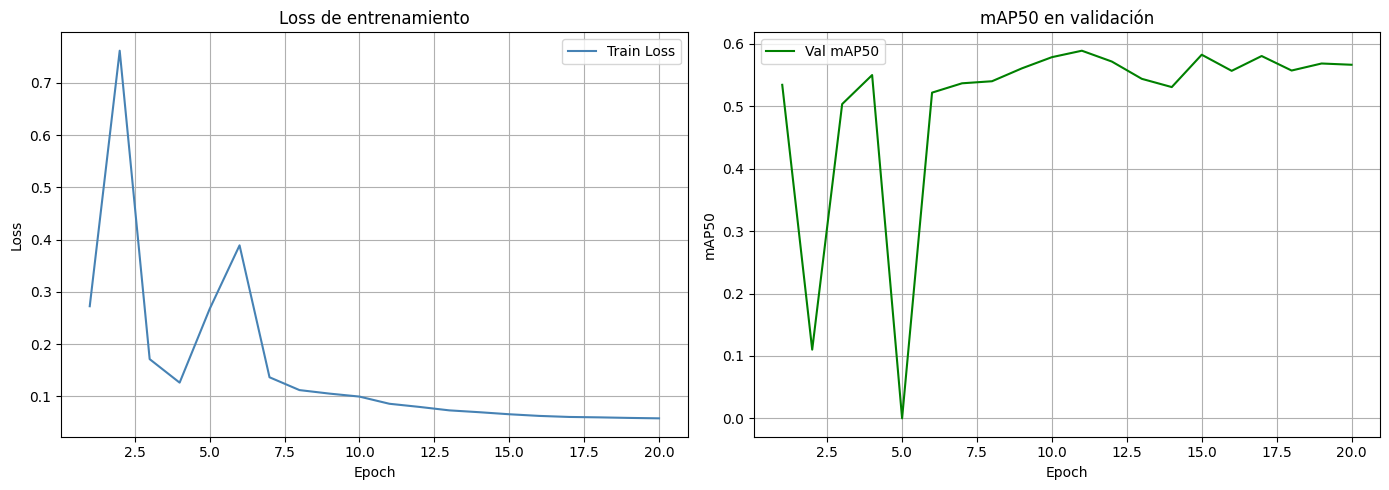


Mejor mAP50: 0.5891 (epoch 11)


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], color='steelblue', label='Train Loss')
ax1.set_title('Loss de entrenamiento')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['val_map50'], color='green', label='Val mAP50')
ax2.set_title('mAP50 en validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP50')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nMejor mAP50: {max(history["val_map50"]):.4f} (epoch {history["val_map50"].index(max(history["val_map50"]))+1})')

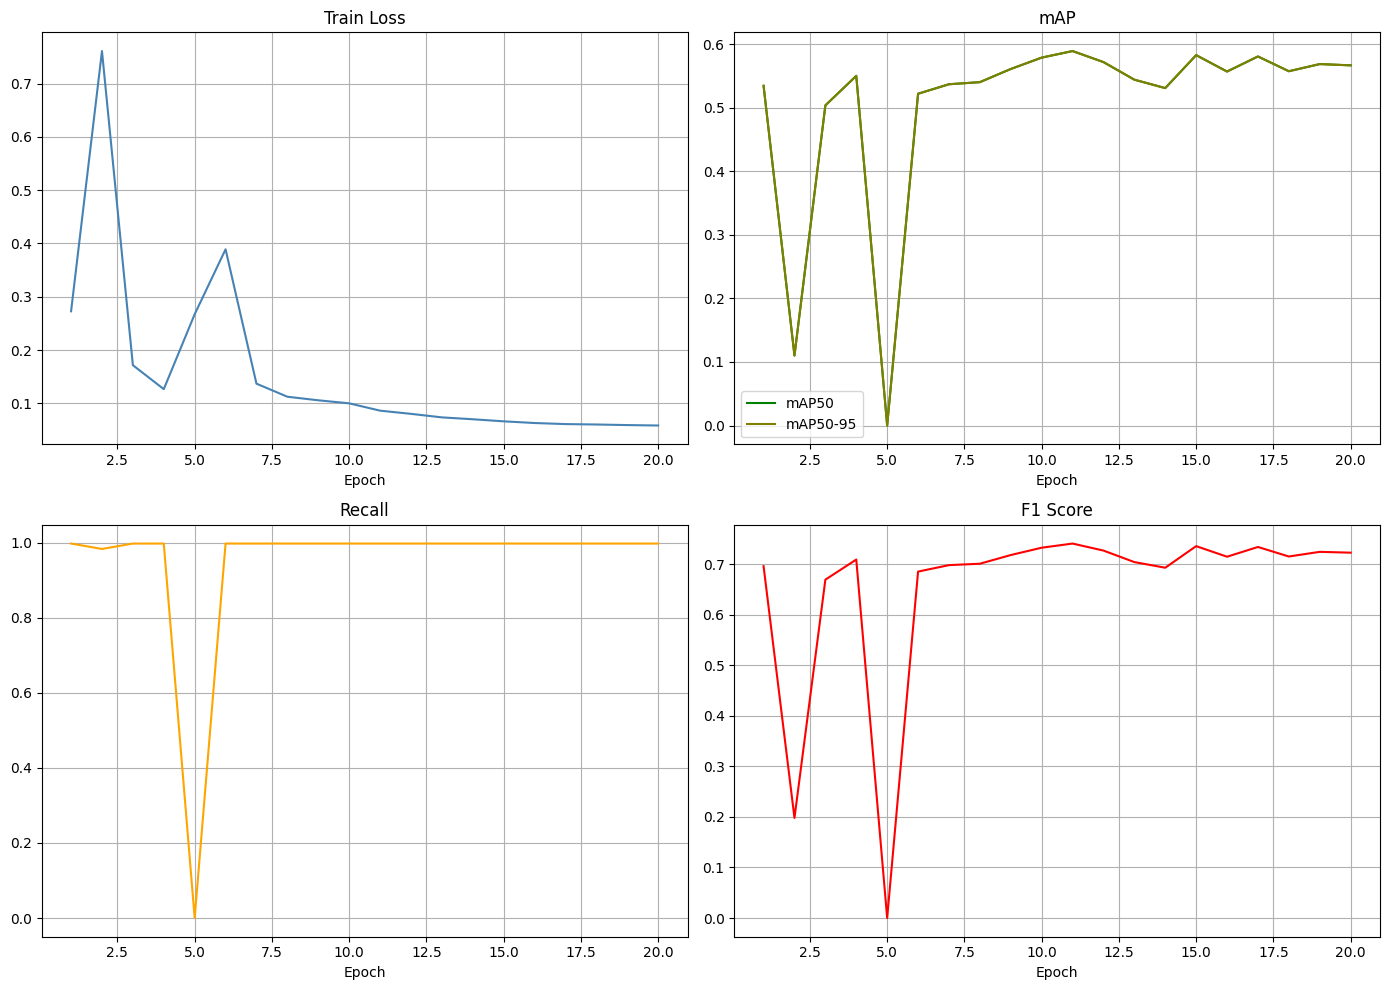


Mejor mAP50:  0.5891
Mejor mAP:    0.5891
Mejor Recall: 0.9974
Mejor F1:     0.7407


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(epochs_range, history['train_loss'], color='steelblue')
axes[0,0].set_title('Train Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True)

axes[0,1].plot(epochs_range, history['val_map50'], color='green', label='mAP50')
axes[0,1].plot(epochs_range, history['val_map'],   color='olive', label='mAP50-95')
axes[0,1].set_title('mAP')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(epochs_range, history['val_recall'], color='orange')
axes[1,0].set_title('Recall')
axes[1,0].set_xlabel('Epoch')
axes[1,0].grid(True)

axes[1,1].plot(epochs_range, history['val_f1'], color='red')
axes[1,1].set_title('F1 Score')
axes[1,1].set_xlabel('Epoch')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f'\nMejor mAP50:  {max(history["val_map50"]):.4f}')
print(f'Mejor mAP:    {max(history["val_map"]):.4f}')
print(f'Mejor Recall: {max(history["val_recall"]):.4f}')
print(f'Mejor F1:     {max(history["val_f1"]):.4f}')

In [ ]:
# Guardar modelo
torch.save(model.state_dict(), 'fasterrcnn_densenet121.pth')
print('Modelo guardado: fasterrcnn_densenet121.pth')

Modelo guardado: fasterrcnn_densenet121.pth
